In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['STHeiti']
plt.rcParams['axes.unicode_minus'] = False

加载数据

In [2]:
# 加载预处理后的数据（从 Feature_Engineering.ipynb 输出）
user_info = pd.read_parquet('data/parquet/user_features_raw_with_cluster.parquet')
order = pd.read_parquet('data/parquet/user_order_cleaned.parquet')
click = pd.read_parquet('data/parquet/user_click.parquet')
item_info = pd.read_parquet('data/parquet/item_data_cleaned.parquet')  # 清洗后商品表

# 查看数据基本信息
print('用户特征数据形状:', user_info.shape)
print('用户特征数据列名:', user_info.columns.tolist())
print('用户订单数据形状:', order.shape)
print('用户订单数据列名:', order.columns.tolist())
print('用户点击数据形状:', click.shape)
print('用户点击数据列名:', click.columns.tolist())
print('商品信息数据形状:', item_info.shape)
print('商品信息数据列名:', item_info.columns.tolist())

用户特征数据形状: (100000, 41)
用户特征数据列名: ['user_id', 'gender', 'age_range', 'F_count', 'order_count', 'unique_order_items', 'total_order_amount', 'avg_order_amount', 'avg_item_price', 'order_span_days', 'avg_items_per_order', 'repeat_item_ratio', 'R_days', 'days_since_first_order', 'days_since_last_order', 'avg_order_interval_days', 'total_clicks', 'unique_clicked_items', 'unique_cid1_clicked', 'unique_cid2_clicked', 'unique_brands_clicked', 'click_span_days', 'avg_clicks_per_day', 'click_to_item_ratio', 'last_click_days', 'first_click_days', 'click_to_buy_ratio', 'order_click_ratio', 'active_days', 'has_order', 'has_click', 'gender_encoded', 'age_encoded', 'log1p_F_count', 'log1p_total_order_amount', 'log1p_total_clicks', 'log1p_unique_clicked_items', 'log1p_unique_order_items', 'log1p_avg_order_amount', 'log1p_avg_item_price', 'cluster']
用户订单数据形状: (1458498, 5)
用户订单数据列名: ['user_id', 'item_id', 'count', 'datetime', 'dt']
用户点击数据形状: (52983323, 4)
用户点击数据列名: ['user_id', 'item_id', 'datetime', 'dt'

定义时间窗口

In [3]:
# 定义时间窗口（确保 datetime 为 datetime 类型）
if not pd.api.types.is_datetime64_any_dtype(order['datetime']):
    order['datetime'] = pd.to_datetime(order['datetime'], format='mixed')
if not pd.api.types.is_datetime64_any_dtype(click['datetime']):
    click['datetime'] = pd.to_datetime(click['datetime'], format='mixed')

order['date'] = order['datetime'].dt.date
click['date'] = click['datetime'].dt.date

max_date = order['date'].max()
print(f"订单日期范围: {order['date'].min()} 到 {max_date}")

last_week_start = max_date - pd.Timedelta(days=6)            # 预测窗口起始
observation_end = last_week_start - pd.Timedelta(days=1)     # 观察期结束
observation_start = observation_end - pd.Timedelta(days=29)  # 30天观察期

print(f"观察期: {observation_start} 到 {observation_end}")
print(f"预测期: {last_week_start} 到 {max_date}")

订单日期范围: 2018-02-18 到 2019-02-18
观察期: 2019-01-13 到 2019-02-11
预测期: 2019-02-12 到 2019-02-18


生成标签

In [4]:
last_week_users = order[order['date'] >= last_week_start]['user_id'].unique()
label_df = pd.DataFrame({'user_id': user_info['user_id'].unique()})
label_df['label'] = label_df['user_id'].isin(last_week_users).astype(int)

构建滑动窗口特征并划分训练/测试集

In [5]:
# 构建观察期特征（滑动窗口）
# 订单特征
order_obs = order[(order['date'] >= observation_start) & (order['date'] <= observation_end)].copy()
order_agg = order_obs.groupby('user_id').agg(
    obs_order_cnt=('datetime', 'count'),
    obs_total_qty=('count', 'sum'),
    obs_unique_items=('item_id', 'nunique'),
    obs_active_days=('date', 'nunique'),
    obs_first_order=('date', 'min'),
    obs_last_order=('date', 'max')
).reset_index()

order_agg['obs_first_order'] = pd.to_datetime(order_agg['obs_first_order'])
order_agg['obs_last_order'] = pd.to_datetime(order_agg['obs_last_order'])
order_agg['obs_order_span'] = (order_agg['obs_last_order'] - order_agg['obs_first_order']).dt.days.replace(0, 1)
order_agg['obs_avg_items_per_order'] = order_agg['obs_total_qty'] / order_agg['obs_order_cnt']
order_agg['obs_avg_interval'] = order_agg['obs_order_span'] / order_agg['obs_order_cnt']
order_agg['obs_days_since_last'] = (pd.to_datetime(last_week_start) - order_agg['obs_last_order']).dt.days
order_agg.drop(['obs_first_order', 'obs_last_order'], axis=1, inplace=True)

In [6]:
# 点击特征
item_features = item_info[['item_id', 'cid1', 'cid2', 'brand_code']].drop_duplicates('item_id')
item_features['item_id'] = item_features['item_id'].astype(str)

click_obs = click[(click['date'] >= observation_start) & (click['date'] <= observation_end)].copy()
click_obs['item_id'] = click_obs['item_id'].astype(str)
click_obs = click_obs.merge(item_features, on='item_id', how='left')

click_agg = click_obs.groupby('user_id').agg(
    click_cnt=('datetime', 'count'),
    unique_click_items=('item_id', 'nunique'),
    unique_cid1=('cid1', 'nunique'),
    unique_cid2=('cid2', 'nunique'),
    unique_brands=('brand_code', 'nunique'),
    click_active_days=('date', 'nunique'),
    first_click=('date', 'min'),
    last_click=('date', 'max')
).reset_index()

click_agg['click_span'] = (pd.to_datetime(click_agg['last_click']) - pd.to_datetime(click_agg['first_click'])).dt.days.replace(0, 1)
click_agg['avg_click_per_day'] = click_agg['click_cnt'] / click_agg['click_active_days']
click_agg['days_since_last_click'] = (pd.to_datetime(last_week_start) - pd.to_datetime(click_agg['last_click'])).dt.days
click_agg.drop(['first_click', 'last_click'], axis=1, inplace=True)

In [7]:
# 合并特征
user_info['user_id'] = user_info['user_id'].astype(str)
order_agg['user_id'] = order_agg['user_id'].astype(str)
click_agg['user_id'] = click_agg['user_id'].astype(str)

features = (user_info[['user_id', 'gender_encoded', 'age_encoded', 'cluster']]
            .merge(order_agg, on='user_id', how='left')
            .merge(click_agg, on='user_id', how='left'))

In [8]:
# 填充缺失值
order_fill_cols = ['obs_order_cnt', 'obs_total_qty', 'obs_unique_items', 'obs_active_days',
                   'obs_order_span', 'obs_avg_items_per_order', 'obs_avg_interval']
click_fill_cols = ['click_cnt', 'unique_click_items', 'unique_cid1', 'unique_cid2',
                   'unique_brands', 'click_active_days', 'click_span', 'avg_click_per_day']

features[order_fill_cols] = features[order_fill_cols].fillna(0)
features[click_fill_cols] = features[click_fill_cols].fillna(0)
features['obs_days_since_last'] = features['obs_days_since_last'].fillna(999)
features['days_since_last_click'] = features['days_since_last_click'].fillna(999)

# 构造转化特征
features['click_to_buy_ratio'] = np.where(features['click_cnt'] > 0, features['obs_order_cnt'] / features['click_cnt'], 0)
features['has_conversion'] = ((features['click_cnt'] > 0) & (features['obs_order_cnt'] > 0)).astype(int)

# 生成标签
last_week_users = order[order['date'] >= last_week_start]['user_id'].unique()
label_df = pd.DataFrame({'user_id': features['user_id'].unique()})
label_df['label'] = label_df['user_id'].isin(last_week_users).astype(int)
features = features.merge(label_df[['user_id', 'label']], on='user_id', how='left')

print("特征矩阵维度:", features.shape)
print("标签分布:\n", features['label'].value_counts(normalize=True))

特征矩阵维度: (100000, 24)
标签分布:
 label
0    0.87014
1    0.12986
Name: proportion, dtype: float64


In [9]:
# 填充缺失值
order_fill_cols = ['obs_order_cnt', 'obs_total_qty', 'obs_unique_items', 'obs_active_days',
                   'obs_order_span', 'obs_avg_items_per_order', 'obs_avg_interval']
click_fill_cols = ['click_cnt', 'unique_click_items', 'unique_cid1', 'unique_cid2',
                   'unique_brands', 'click_active_days', 'click_span', 'avg_click_per_day']

features[order_fill_cols] = features[order_fill_cols].fillna(0)
features[click_fill_cols] = features[click_fill_cols].fillna(0)

# 对无订单/无点击用户，距最后行为天数填充为观察窗口长度+缓冲（而非固定999）
obs_window_days = (last_week_start - observation_start).days + 30  # ~60天
features['obs_days_since_last'] = features['obs_days_since_last'].fillna(obs_window_days)
features['days_since_last_click'] = features['days_since_last_click'].fillna(obs_window_days)

# 构造转化特征
features['click_to_buy_ratio'] = np.where(features['click_cnt'] > 0, features['obs_order_cnt'] / features['click_cnt'], 0)
features['has_conversion'] = ((features['click_cnt'] > 0) & (features['obs_order_cnt'] > 0)).astype(int)

# 生成标签
if 'label' in features.columns:
    features = features.drop(columns=['label'])
    
last_week_users = order[order['date'] >= last_week_start]['user_id'].unique()
label_df = pd.DataFrame({'user_id': features['user_id'].unique()})
label_df['label'] = label_df['user_id'].isin(last_week_users).astype(int)
features = features.merge(label_df[['user_id', 'label']], on='user_id', how='left')

print("特征矩阵维度:", features.shape)
print("标签分布:\n", features['label'].value_counts(normalize=True))

特征矩阵维度: (100000, 24)
标签分布:
 label
0    0.87014
1    0.12986
Name: proportion, dtype: float64


In [10]:
# 时间顺序划分训练/测试集：使用固定日期切分
# 以观察窗口的时间中位数作为划分点
time_cutoff = observation_start + (observation_end - observation_start) * 0.7

# 计算每个用户在观察期的最后活跃时间
order_last = order_obs.groupby('user_id')['date'].max().reset_index()
order_last.rename(columns={'date': 'last_order'}, inplace=True)
order_last['last_order'] = pd.to_datetime(order_last['last_order'])
order_last['user_id'] = order_last['user_id'].astype(str)

click_last = click_obs.groupby('user_id')['date'].max().reset_index()
click_last.rename(columns={'date': 'last_click'}, inplace=True)
click_last['last_click'] = pd.to_datetime(click_last['last_click'])
click_last['user_id'] = click_last['user_id'].astype(str)

last_activity = features[['user_id']].copy()
last_activity = (last_activity.merge(order_last, on='user_id', how='left')
                              .merge(click_last, on='user_id', how='left'))
last_activity['last_active'] = last_activity[['last_order', 'last_click']].max(axis=1)
last_activity['last_active'] = last_activity['last_active'].fillna(pd.Timestamp('2018-01-01'))

features_with_time = features.merge(last_activity[['user_id', 'last_active']], on='user_id')

# 按固定时间点划分，而非百分位
train = features_with_time[features_with_time['last_active'] < pd.Timestamp(time_cutoff)]
test = features_with_time[features_with_time['last_active'] >= pd.Timestamp(time_cutoff)]
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

print(f"时间切分点: {time_cutoff}")
print(f"训练集大小: {len(train)}, 测试集大小: {len(test)}")
print(f"训练集标签均值: {train['label'].mean():.4f}, 测试集标签均值: {test['label'].mean():.4f}")

时间切分点: 2019-02-02
训练集大小: 64623, 测试集大小: 35377
训练集标签均值: 0.0494, 测试集标签均值: 0.2769


In [11]:
# cluster 仅用于画像分析，不参与预测建模（其计算依赖全量 RFM 特征，直接使用会导致数据泄露）
feature_cols = [
    'gender_encoded', 'age_encoded',
    'obs_order_cnt', 'obs_total_qty', 'obs_unique_items', 'obs_active_days',
    'obs_order_span', 'obs_avg_items_per_order', 'obs_avg_interval',
    'obs_days_since_last', 'click_cnt', 'unique_click_items', 'unique_cid1', 'unique_cid2',
    'unique_brands', 'click_active_days', 'click_span', 'avg_click_per_day',
    'days_since_last_click', 'click_to_buy_ratio', 'has_conversion'
]

X_train_raw = train[feature_cols]
y_train = train['label'].values
X_test_raw = test[feature_cols]
y_test = test['label'].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, average_precision_score, 
                             fbeta_score, roc_curve, precision_recall_curve)
from sklearn.model_selection import RandomizedSearchCV

基础模型训练

In [13]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=300, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=15,
                                           random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(class_weight='balanced', n_estimators=200, random_state=42, verbose=-1)
}

proba_dict = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    proba_dict[name] = model.predict_proba(X_test)[:, 1]
    print(f"{name} 训练完成")


Logistic Regression 训练完成
Decision Tree 训练完成
Random Forest 训练完成
LightGBM 训练完成


LightGBM 调参

In [14]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5]
}

sample_idx = np.random.RandomState(42).choice(len(X_train), size=min(5000, len(X_train)), replace=False)
X_sample, y_sample = X_train[sample_idx], y_train[sample_idx]

f2_scorer = lambda y_true, y_pred: fbeta_score(y_true, y_pred, beta=2)
lgb_base = lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
search = RandomizedSearchCV(lgb_base, param_dist, n_iter=10, scoring=f2_scorer,
                            cv=3, random_state=42, n_jobs=-1, verbose=0)
search.fit(X_sample, y_sample)
print(f"LightGBM 最优参数: {search.best_params_}")

lgb_tuned = lgb.LGBMClassifier(**search.best_params_, class_weight='balanced', random_state=42)
lgb_tuned.fit(X_train, y_train)
proba_dict['LightGBM Tuned'] = lgb_tuned.predict_proba(X_test)[:, 1]


LightGBM 最优参数: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.5, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


阈值优化（F2）

In [15]:
thresholds = np.arange(0.1, 0.9, 0.05)
optimal_thresholds = {}
for name, proba in proba_dict.items():
    f2_scores = [fbeta_score(y_test, (proba >= t).astype(int), beta=2) for t in thresholds]
    best_idx = np.argmax(f2_scores)
    optimal_thresholds[name] = thresholds[best_idx]
    print(f"{name}: 最优阈值 = {optimal_thresholds[name]:.2f}, F2 = {f2_scores[best_idx]:.4f}")

pred_dict = {name: (proba_dict[name] >= optimal_thresholds[name]).astype(int) 
             for name in proba_dict}


Logistic Regression: 最优阈值 = 0.70, F2 = 0.6604
Decision Tree: 最优阈值 = 0.60, F2 = 0.5935
Random Forest: 最优阈值 = 0.10, F2 = 0.6359
LightGBM: 最优阈值 = 0.10, F2 = 0.6550
LightGBM Tuned: 最优阈值 = 0.10, F2 = 0.6570


模型评估与可视化


>>> Logistic Regression
              precision    recall  f1-score   support

         未下单       0.88      0.19      0.31     25581
          下单       0.31      0.93      0.46      9796

    accuracy                           0.39     35377
   macro avg       0.59      0.56      0.38     35377
weighted avg       0.72      0.39      0.35     35377



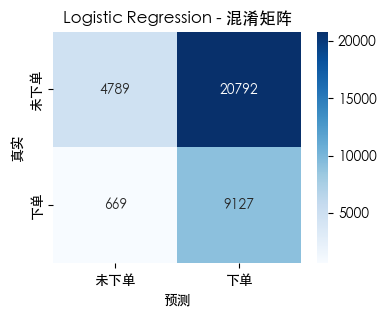

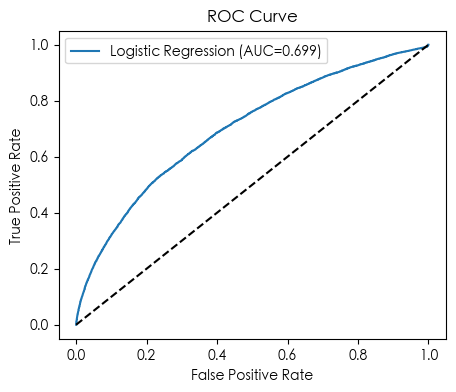

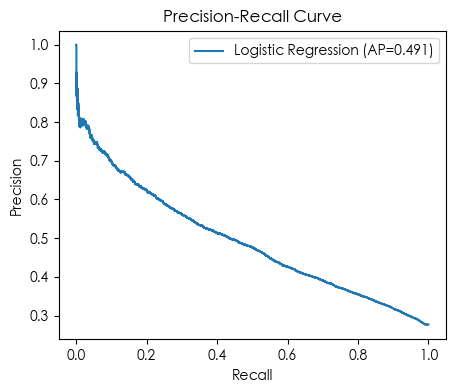

  AUC = 0.6988, AP = 0.4906

>>> Decision Tree
              precision    recall  f1-score   support

         未下单       0.74      0.20      0.31     25581
          下单       0.28      0.82      0.42      9796

    accuracy                           0.37     35377
   macro avg       0.51      0.51      0.37     35377
weighted avg       0.62      0.37      0.34     35377



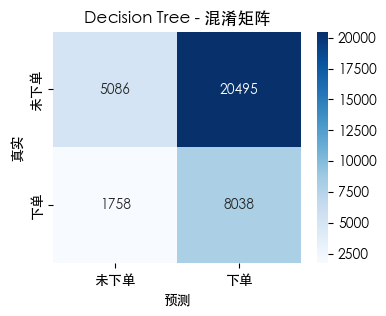

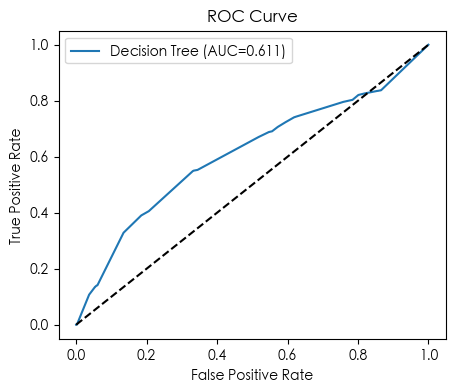

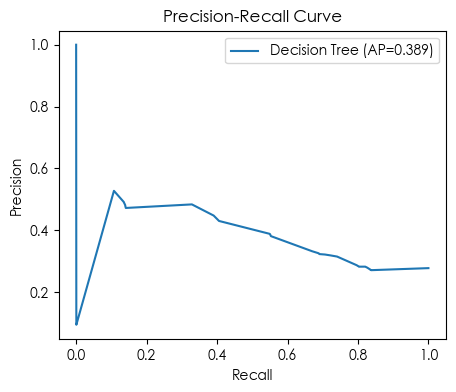

  AUC = 0.6114, AP = 0.3886

>>> Random Forest
              precision    recall  f1-score   support

         未下单       0.48      0.01      0.03     25581
          下单       0.27      0.96      0.42      9796

    accuracy                           0.28     35377
   macro avg       0.37      0.49      0.23     35377
weighted avg       0.42      0.28      0.14     35377



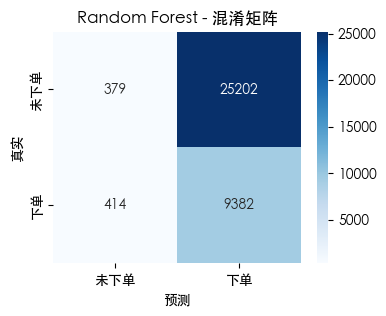

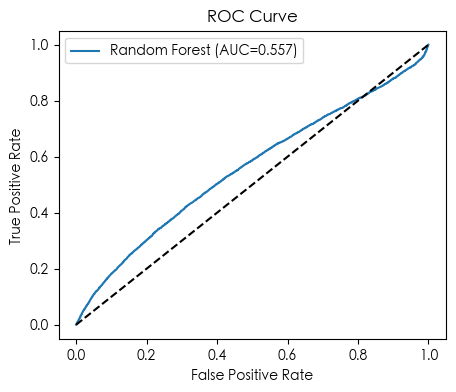

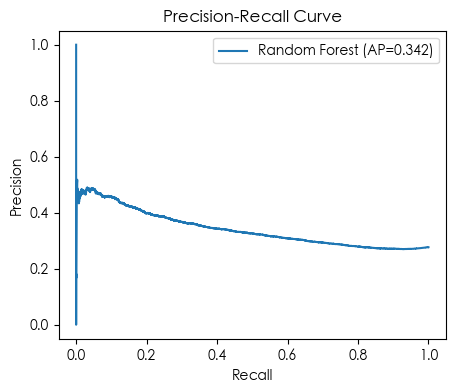

  AUC = 0.5571, AP = 0.3418

>>> LightGBM
              precision    recall  f1-score   support

         未下单       0.79      0.01      0.02     25581
          下单       0.28      0.99      0.43      9796

    accuracy                           0.28     35377
   macro avg       0.53      0.50      0.23     35377
weighted avg       0.65      0.28      0.14     35377



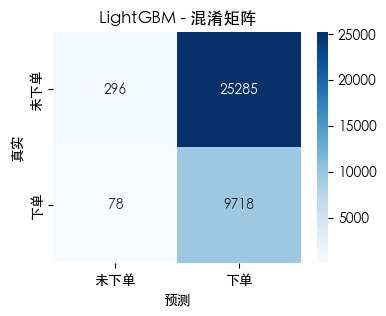

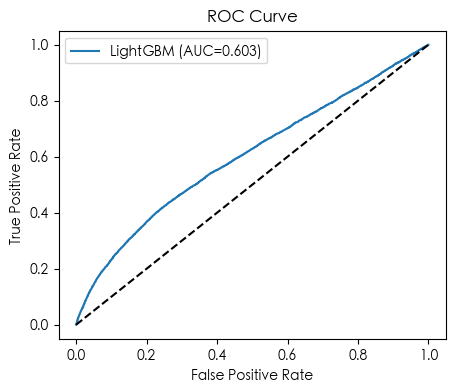

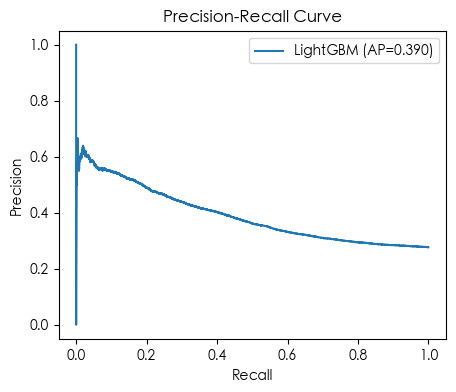

  AUC = 0.6027, AP = 0.3900

>>> LightGBM Tuned
              precision    recall  f1-score   support

         未下单       0.90      0.00      0.00     25581
          下单       0.28      1.00      0.43      9796

    accuracy                           0.28     35377
   macro avg       0.59      0.50      0.22     35377
weighted avg       0.73      0.28      0.12     35377



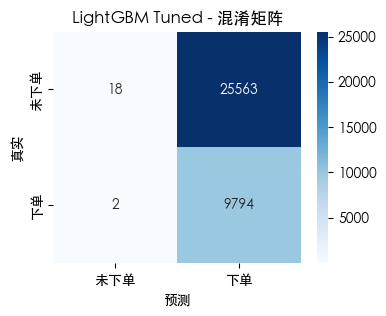

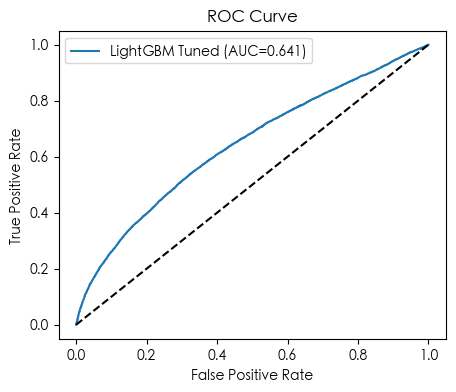

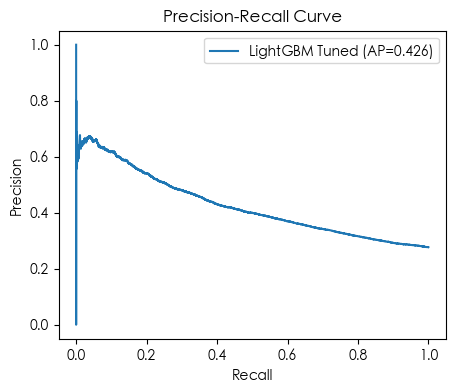

  AUC = 0.6408, AP = 0.4256


In [16]:
for name in pred_dict:
    print(f"\n>>> {name}")
    print(classification_report(y_test, pred_dict[name], target_names=['未下单', '下单']))
    
    # 混淆矩阵
    cm = confusion_matrix(y_test, pred_dict[name])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['未下单', '下单'], yticklabels=['未下单', '下单'])
    plt.title(f'{name} - 混淆矩阵')
    plt.xlabel('预测')
    plt.ylabel('真实')
    plt.show()
    
    # ROC 曲线
    fpr, tpr, _ = roc_curve(y_test, proba_dict[name])
    auc = roc_auc_score(y_test, proba_dict[name])
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
    
    # PR 曲线
    precision, recall, _ = precision_recall_curve(y_test, proba_dict[name])
    ap = average_precision_score(y_test, proba_dict[name])
    plt.figure(figsize=(5,4))
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()
    print(f"  AUC = {auc:.4f}, AP = {ap:.4f}")


特征重要性

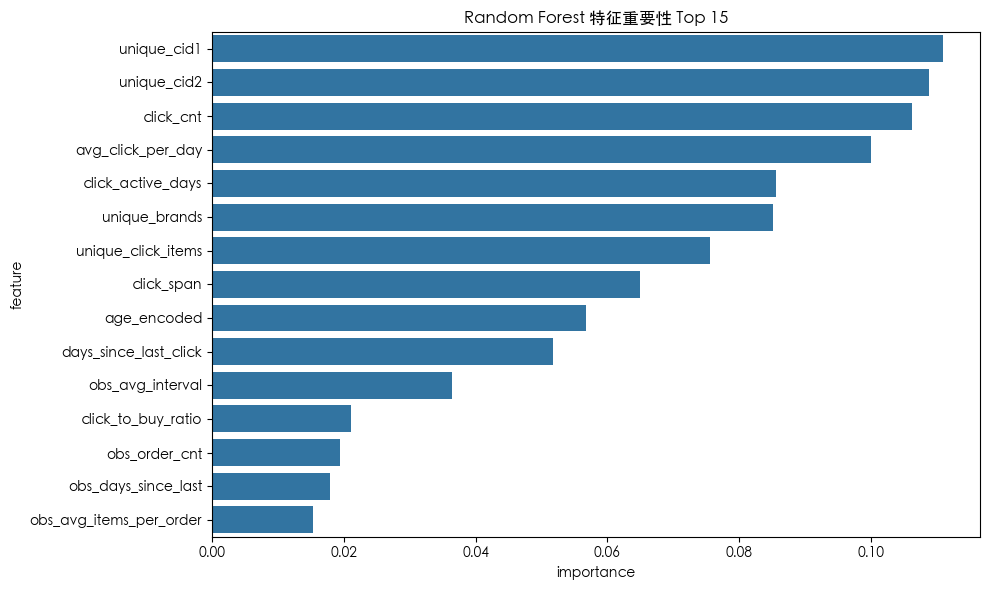

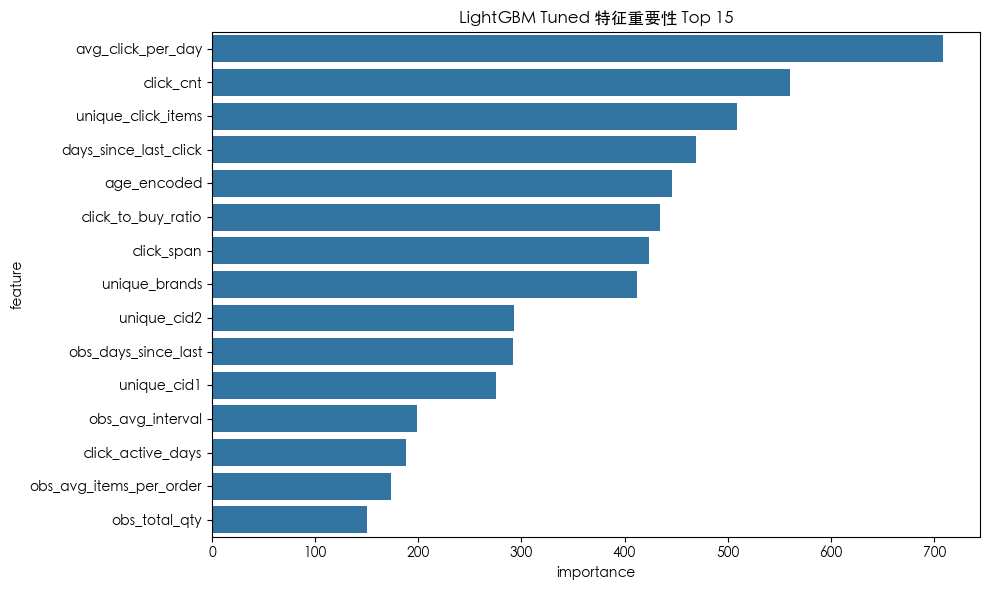

RF  Top 5:
               feature  importance
12        unique_cid1    0.110966
13        unique_cid2    0.108779
10          click_cnt    0.106190
17  avg_click_per_day    0.100054
15  click_active_days    0.085584
LGB Top 5:
                   feature  importance
17      avg_click_per_day         709
10              click_cnt         560
11     unique_click_items         509
18  days_since_last_click         469
1             age_encoded         446


In [17]:
rf_model = models['Random Forest']
lgb_model = lgb_tuned

# Random Forest
rf_imp = pd.DataFrame({'feature': feature_cols, 'importance': rf_model.feature_importances_}
                     ).sort_values('importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=rf_imp.head(15))
plt.title('Random Forest 特征重要性 Top 15')
plt.tight_layout()
plt.show()

# LightGBM Tuned
lgb_imp = pd.DataFrame({'feature': feature_cols, 'importance': lgb_model.feature_importances_}
                      ).sort_values('importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=lgb_imp.head(15))
plt.title('LightGBM Tuned 特征重要性 Top 15')
plt.tight_layout()
plt.show()

print("RF  Top 5:\n", rf_imp.head(5))
print("LGB Top 5:\n", lgb_imp.head(5))

In [18]:
print("="*60)
print("最终模型性能总结（测试集）")
print("="*60)
for name in pred_dict:
    auc = roc_auc_score(y_test, proba_dict[name])
    ap  = average_precision_score(y_test, proba_dict[name])
    f2  = fbeta_score(y_test, pred_dict[name], beta=2)
    print(f"{name:20s}: AUC={auc:.4f}, AP={ap:.4f}, F2={f2:.4f}")

最终模型性能总结（测试集）
Logistic Regression : AUC=0.6988, AP=0.4906, F2=0.6604
Decision Tree       : AUC=0.6114, AP=0.3886, F2=0.5935
Random Forest       : AUC=0.5571, AP=0.3418, F2=0.6359
LightGBM            : AUC=0.6027, AP=0.3900, F2=0.6550
LightGBM Tuned      : AUC=0.6408, AP=0.4256, F2=0.6570
